# Iterated Prisoner's Dilemma — Tournament Analysis

Exploratory analysis of the **Gold layer** produced by the pipeline.

**Prerequisite**: generate at least one run end-to-end first (see the README):

```bash
uv run dagster asset materialize --select "*" -m convicts_dilemma.defs
```

Everything below reads the Gold Parquet files only — no raw rows, exactly
what a data analyst is meant to consume. Launch with:

```bash
uv sync --group analysis
uv run jupyter lab notebooks/analysis.ipynb
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Works whether the notebook is launched from the repo root or notebooks/.
GOLD = next(p for p in (Path("data/gold"), Path("../data/gold")) if p.exists())

catalog = pl.read_parquet(GOLD / "run_catalog.parquet").sort("created_at")
catalog.select("run_id", "created_at", "seed", "n_rounds", "payoff_temptation", "n_matches")

run_id,created_at,seed,n_rounds,payoff_temptation,n_matches
str,"datetime[μs, UTC]",i64,i64,i64,i64
"""20260611T122319-17e613a0""",2026-06-11 12:23:19.107786 UTC,42,2000,5,55
"""20260611T140348-4ee0ac59""",2026-06-11 14:03:48.288225 UTC,42,2000,5,55


We analyse the most recent run played with the **classic Axelrod payoffs**
(T=5, R=3, P=1, S=0); other runs are used in the cross-run section at the end.

In [2]:
classic = catalog.filter(pl.col("payoff_temptation") == 5)
RUN = classic["run_id"][-1]
print(f"analysing run: {RUN}")

summary = (
    pl.read_parquet(GOLD / "tournament_summary.parquet")
    .filter(pl.col("run_id") == RUN)
    .sort("rank")
)
summary.select("rank", "player", "total_score", "avg_score_per_round", "coop_rate", "wins", "losses", "draws")

analysing run: 20260611T140348-4ee0ac59


rank,player,total_score,avg_score_per_round,coop_rate,wins,losses,draws
i64,str,f64,f64,f64,f64,f64,f64
1,"""generous_tit_for_tat""",58117.0,2.641682,0.830409,0.0,4.0,7.0
2,"""tit_for_two_tats""",56809.0,2.582227,0.823136,0.0,4.0,7.0
3,"""always_cooperate""",56355.0,2.561591,1.0,0.0,4.0,7.0
4,"""tit_for_tat""",55432.0,2.519636,0.726227,0.0,2.0,9.0
5,"""pavlov""",55256.0,2.511636,0.789455,0.0,3.0,8.0
6,"""grim_trigger""",54162.0,2.461909,0.637045,1.0,1.0,9.0
7,"""random""",47748.0,2.170364,0.500455,5.0,5.0,1.0
8,"""suspicious_tit_for_tat""",41617.0,1.891682,0.395364,4.0,0.0,7.0
9,"""always_defect""",38772.0,1.762364,0.0,8.0,0.0,3.0


## 1. Leaderboard — cooperation pays

Axelrod's central result: the strategies that score best are *nice*
(never defect first) but *retaliatory*. Note the paradox at the bottom:
`always_defect` **wins** most of its matches yet ends with one of the worst
total scores — it wins battles and loses the war, because mutual defection
(1+1) creates far less value than mutual cooperation (3+3).

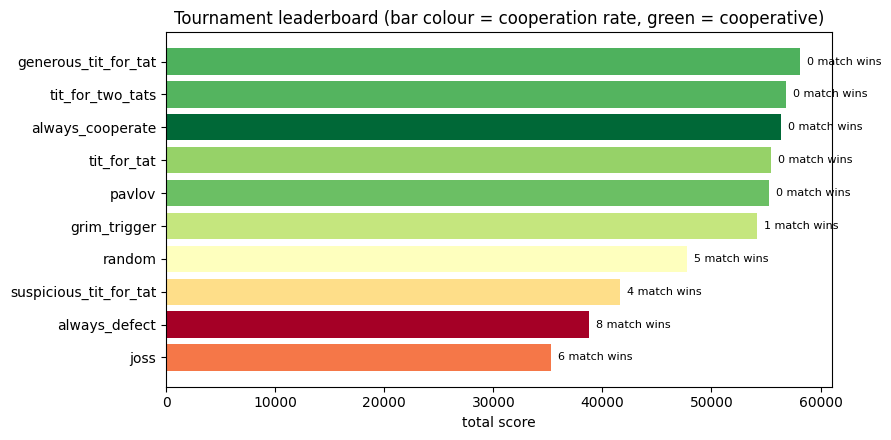

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = plt.cm.RdYlGn(summary["coop_rate"].to_numpy())
ax.barh(summary["player"].to_list(), summary["total_score"].to_list(), color=colors)
ax.invert_yaxis()
ax.set_xlabel("total score")
ax.set_title("Tournament leaderboard (bar colour = cooperation rate, green = cooperative)")
for i, (score, wins) in enumerate(zip(summary["total_score"], summary["wins"])):
    ax.text(score, i, f"  {int(wins)} match wins", va="center", fontsize=8)
plt.tight_layout()

## 2. Matchup heatmap

Average score of the **row** strategy against the **column** strategy.
The bright diagonal block among the top-ranked strategies is the mutual-
cooperation club (score 3/round → 6000); exploiter rows (`always_defect`,
`joss`) only shine against `always_cooperate` and `random`.

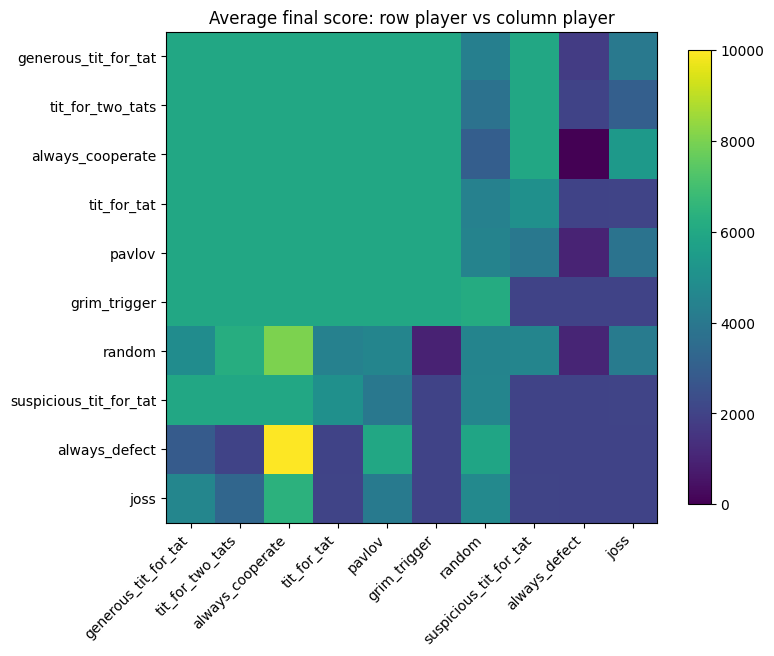

In [4]:
matchups = pl.read_parquet(GOLD / "matchup_matrix.parquet").filter(pl.col("run_id") == RUN)
order = summary["player"].to_list()  # rank order
lookup = {(r["player"], r["opponent"]): r["player_score"] for r in matchups.iter_rows(named=True)}
matrix = np.array([[lookup.get((p, o), np.nan) for o in order] for p in order])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, cmap="viridis")
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_title("Average final score: row player vs column player")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()

## 3. Behavioural drift

Cooperation rate per 100-round bucket. Flat lines are unconditional or
locked-in behaviours; the interesting signals are early drops (echo feuds
triggered in the first rounds, e.g. `grim_trigger` punishing `joss`'s first
sneak defection forever) and the noisy band of `random`-driven matches.

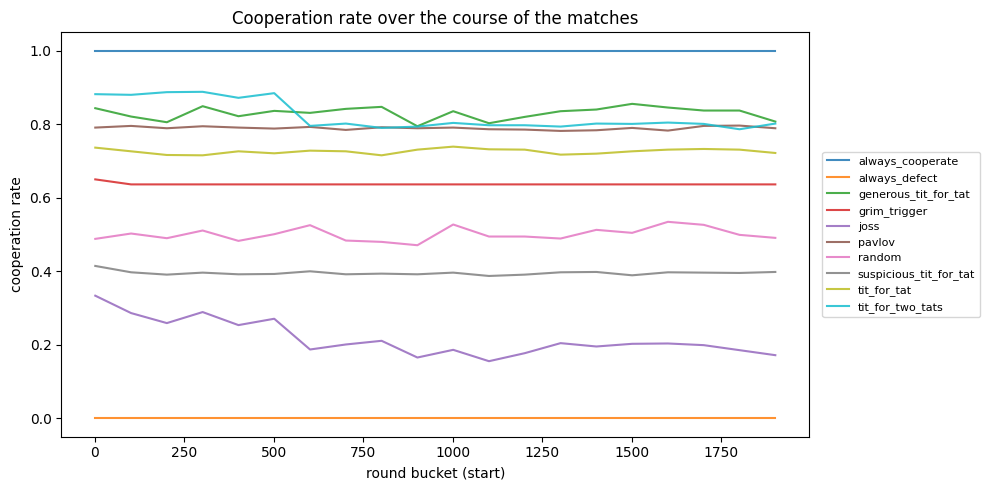

In [5]:
drift = (
    pl.read_parquet(GOLD / "behavioral_drift.parquet")
    .filter(pl.col("run_id") == RUN)
    .sort("round_bucket")
)

fig, ax = plt.subplots(figsize=(10, 5))
for (player,), group in drift.group_by("player", maintain_order=True):
    ax.plot(group["round_bucket"], group["coop_rate"], label=player, alpha=0.85)
ax.set_xlabel("round bucket (start)")
ax.set_ylabel("cooperation rate")
ax.set_title("Cooperation rate over the course of the matches")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()

## 4. Does forgiveness pay?

`forgiveness_rate` = share of rounds right after a betrayal where the
strategy returned to cooperation. Pure retaliators sit at 0; the sweet spot
in this roster is *mostly* retaliatory with a little forgiveness
(`generous_tit_for_tat`, `tit_for_two_tats`) — enough to break echo feuds,
not enough to be exploitable.

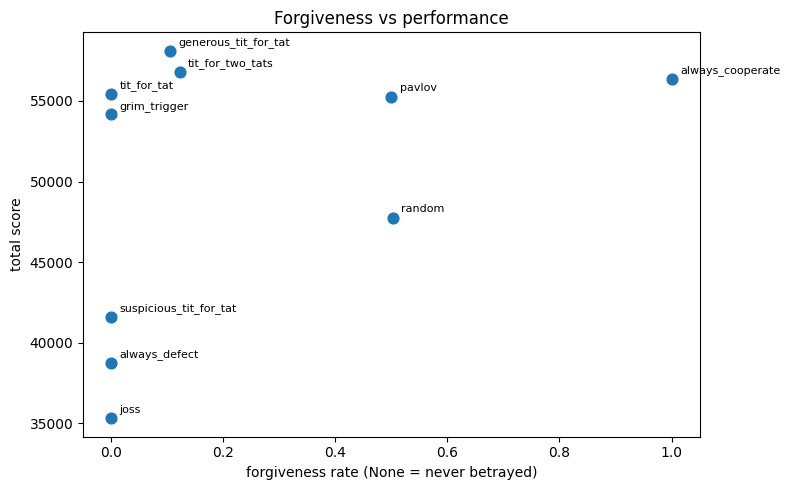

In [6]:
forgiveness = pl.read_parquet(GOLD / "forgiveness_index.parquet").filter(pl.col("run_id") == RUN)
joined = forgiveness.join(summary.select("player", "total_score"), on="player")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(joined["forgiveness_rate"], joined["total_score"], s=60)
for row in joined.iter_rows(named=True):
    ax.annotate(row["player"], (row["forgiveness_rate"], row["total_score"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("forgiveness rate (None = never betrayed)")
ax.set_ylabel("total score")
ax.set_title("Forgiveness vs performance")
plt.tight_layout()

## 5. Across runs — the versioned lake at work

`cross_run_summary` joins every run's leaderboard with its parameters.
Below, each strategy's **rank per run**: comparing a re-seeded run (sampling
noise only) with a run where the temptation payoff is raised to T=10
(betrayal pays double) shows which results are robust and which depend on
the payoff structure.

In [ ]:
cross = (
    pl.read_parquet(GOLD / "cross_run_summary.parquet")
    .sort("created_at")
    .with_columns(
        # The run_id suffix keeps labels unique even when several runs share
        # the same configuration (the pivot below requires one value per cell).
        run_label=pl.format(
            "seed={} T={} [{}]",
            pl.col("seed"),
            pl.col("payoff_temptation"),
            pl.col("run_id").str.slice(-8),
        )
    )
)
ranks = cross.pivot(on="run_label", index="player", values="rank").sort(
    pl.mean_horizontal(pl.all().exclude("player"))
)
ranks

In [ ]:
labels = [c for c in ranks.columns if c != "player"]
fig, ax = plt.subplots(figsize=(8, 5.5))
for row in ranks.iter_rows(named=True):
    ax.plot(labels, [row[c] for c in labels], marker="o", label=row["player"], alpha=0.8)
ax.invert_yaxis()
ax.set_ylabel("rank (1 = best)")
ax.set_title("Strategy rank across runs")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()

## 6. Reading the results: Nash equilibrium vs emergence

- In the **one-shot** prisoner's dilemma, mutual defection is the unique
  Nash equilibrium: whatever the opponent does, defecting pays more.
  `always_defect` embodies that logic — and its match record (most wins,
  almost no losses) shows the equilibrium reasoning is locally correct.
- In the **iterated** game with an unknown horizon, the leaderboard inverts:
  the value lost to mutual defection compounds, and *nice + retaliatory +
  forgiving + clear* strategies (Axelrod's four properties) dominate.
  Cooperation **emerges** without any altruism in the agents' objectives.
- Raising the temptation payoff (T=10 run) is a robustness probe: if
  exploiters climb the ranking, the cooperative equilibrium is fragile to
  the payoff structure — exactly the kind of question the versioned lake
  exists to answer with one more `dagster asset materialize`.
- With LLM agents in the roster (`llm_*` strategies), the same tables tell
  you whether a persona prompt actually translates into measurable
  behaviour (cooperation rate, forgiveness) — and the `reasoning` column in
  Silver lets you read *why* an agent says it defected.